In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

ds_jobs = pd.read_csv("../data/processed/ds_jobs.csv")

print("Dataset loaded successfully!")
print(ds_jobs.shape)

Dataset loaded successfully!
(1307, 31)


In [2]:
ds_jobs[["title", "description"]].head()

,title,description
0,Sr Data Engineer with Kafka,Data Engineer with Kafka (W2 Only)💯% Remote\nM...
1,Cloud Platform/ Big Data Engineer,About Subaru Research and Development:Do you c...
2,Data Engineer/ETL,"Responsibilities:Develop new features, fix bug..."
3,Data Analyst,Job Title: Data AnalystDuration: ContractLocat...
4,Senior Data Engineer/Analyst - Full Time,"Job Type: Full-Time, Permanent \nResponsibilit..."


In [3]:
skills = [
    "Python", "SQL", "Power BI", "Tableau", "Excel",
    "AWS", "Azure", "Snowflake", "Kafka", "Spark",
    "Hadoop", "Git", "Linux", "Docker", "ETL",
    "Machine Learning", "Deep Learning", "TensorFlow",
    "PyTorch", "Pandas", "NumPy", "Statistics"
]

print("Total skills:", len(skills))

Total skills: 22


In [4]:
skill_counts = {}

descriptions = ds_jobs["description"].fillna("").astype(str)

for skill in skills:
    pattern = r"\b" + re.escape(skill.lower()) + r"\b"
    
    count = descriptions.str.lower().str.contains(
        pattern,
        regex=True
    ).sum()
    
    skill_counts[skill] = count

skill_counts

{'Python': np.int64(764),
 'SQL': np.int64(790),
 'Power BI': np.int64(177),
 'Tableau': np.int64(235),
 'Excel': np.int64(215),
 'AWS': np.int64(340),
 'Azure': np.int64(273),
 'Snowflake': np.int64(147),
 'Kafka': np.int64(69),
 'Spark': np.int64(242),
 'Hadoop': np.int64(114),
 'Git': np.int64(76),
 'Linux': np.int64(46),
 'Docker': np.int64(68),
 'ETL': np.int64(264),
 'Machine Learning': np.int64(434),
 'Deep Learning': np.int64(104),
 'TensorFlow': np.int64(88),
 'PyTorch': np.int64(97),
 'Pandas': np.int64(45),
 'NumPy': np.int64(31),
 'Statistics': np.int64(307)}

In [5]:
skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Count"]
)

skill_df = skill_df.sort_values(
    by="Count",
    ascending=False
)

skill_df.head(15)

,Skill,Count
1,SQL,790
0,Python,764
15,Machine Learning,434
5,AWS,340
21,Statistics,307
6,Azure,273
14,ETL,264
9,Spark,242
3,Tableau,235
4,Excel,215


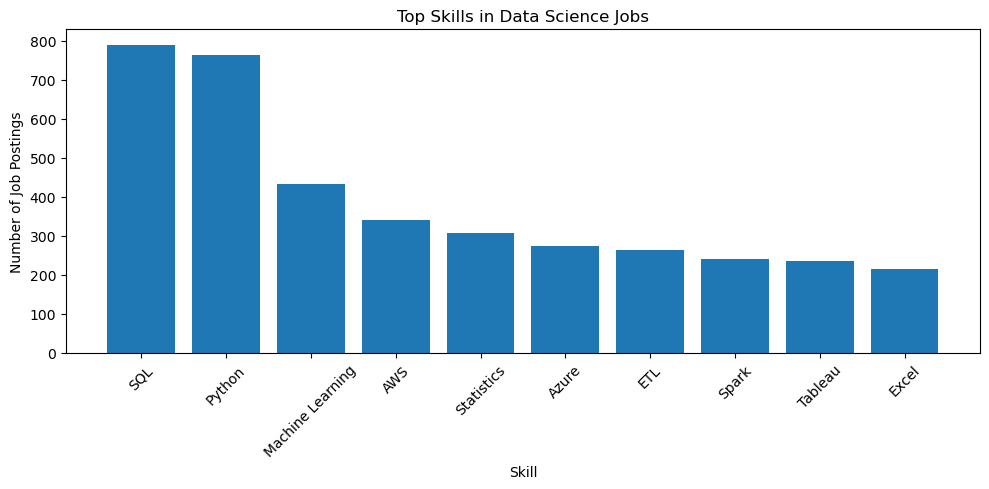

In [6]:
top_skills = skill_df.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_skills["Skill"], top_skills["Count"])
plt.xticks(rotation=45)
plt.title("Top Skills in Data Science Jobs")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

In [7]:
skill_df.head(15)

,Skill,Count
1,SQL,790
0,Python,764
15,Machine Learning,434
5,AWS,340
21,Statistics,307
6,Azure,273
14,ETL,264
9,Spark,242
3,Tableau,235
4,Excel,215


In [8]:
skill_df.to_csv(
    "../data/processed/skill_demand.csv",
    index=False
)

print("Skill Demand Dataset Saved!")

Skill Demand Dataset Saved!
